### [ 주제: 빙어, 도미 분류 ]
- 데이터: fish.csv
- 특성/ 피처: Height, Weight, Length
- 타겟: Species-> Bream, smelt 만 분류
- 학습 종류: 지도학습- 분류
- 학습 방법: KNN- 최근접이웃법


- **[0] 모듈 로딩**

In [2]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC

## 모델
from sklearn.neighbors import KNeighborsClassifier 


from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

## 교차검증+ 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV 

- **[1] 데이터 준비**
    * 데이터 파일/ 폴더 설정
    * 데이터 로딩
    * 데이터 기본 정보 확인: info()+ head()/ tail(), describe(include='all')

In [3]:
DATA_FILE= '../Data/Numbers/fish.csv'

In [4]:
##=> 데이터 로딩 : 첫번째 줄 컬럼명, 쉼표(,) 구분자
##=> 행: 품종 Bream, Smelt인 행
##=> 컬럼 : 'Species', 'Weight','Width','Height'

fishDF = pd.read_csv(DATA_FILE, 
                    usecols=['Species', 'Weight', 'Length', 'Height' ],   
                    skiprows=range(36, 146))

fishDF

,Species,Weight,Length,Height
0,Bream,242.0,25.4,11.5200
1,Bream,290.0,26.3,12.4800
2,Bream,340.0,26.5,12.3778
3,Bream,363.0,29.0,12.7300
4,Bream,430.0,29.0,12.4440
5,Bream,450.0,29.7,13.6024
6,Bream,500.0,29.7,14.1795
7,Bream,390.0,30.0,12.6700
8,Bream,450.0,30.0,14.0049
9,Bream,500.0,30.7,14.2266


In [5]:
## 데이터 기본 정보
## 컬럼에 결측치, 타입 체크--> 자료형 변환 여부

fishDF.info()
display(fishDF.head(3))


# 컬럼별 데이터 분포
## 품종 컬럼: 불균형 데이터---> Bream: Smelt= 35: 14
# 나머지 컬럼: 평균< 중간값--> 오른쪽으로 약간 치우침
print("=" *60)
display(fishDF.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     object 
 1   Weight   49 non-null     float64
 2   Length   49 non-null     float64
 3   Height   49 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


,Species,Weight,Length,Height
0,Bream,242.0,25.4,11.5200
1,Bream,290.0,26.3,12.4800
2,Bream,340.0,26.5,12.3778


,Species,Weight,Length,Height
count,49,49.000000,49.000000,49.000000
unique,2,NaN,NaN,NaN
top,Bream,NaN,NaN,NaN
freq,35,NaN,NaN,NaN
mean,NaN,444.500000,27.055102,11.476400
std,NaN,328.143233,10.242804,6.150976
min,NaN,6.700000,9.800000,1.728400
25%,NaN,19.700000,14.300000,2.872800
50%,NaN,500.000000,31.000000,14.179500
75%,NaN,700.000000,34.500000,15.633000


In [6]:
fishDF.Species=fishDF.Species.astype('category')

display(fishDF.dtypes)

Species    category
Weight      float64
Length      float64
Height      float64
dtype: object

In [7]:
## => 피쳐와 타겟 분리
featureDF = fishDF[['Weight', 'Height', 'Length']]
targetSR = fishDF['Species']

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')

피쳐 : (49, 3), 타겟 : (49,)


- **[2] 피처로 타겟 분류가능 여부 체크**

In [8]:
# 도미, 빙어 데이터만 추출
fishDF = fishDF[fishDF['Species'].isin(['Bream', 'Smelt'])].copy()

# 타겟을 category 타입으로 변경
fishDF['Species'] = fishDF['Species'].astype('category')

# 피쳐와 타겟 분리
featureDF = fishDF[['Weight', 'Height', 'Length']]
targetSR = fishDF['Species']

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')
print(targetSR.value_counts())

피쳐 : (49, 3), 타겟 : (49,)
Species
Bream    35
Smelt    14
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    featureDF,
    targetSR,
    test_size=0.2,
    random_state=10,
    stratify=targetSR
)

print(f'학습용 : {X_train.shape}, {y_train.shape}')
print(f'테스트용 : {X_test.shape}, {y_test.shape}')

print('\n학습용 클래스 데이터 구성')
print(y_train.value_counts())

print('\n테스트용 클래스 데이터 구성')
print(y_test.value_counts())

학습용 : (39, 3), (39,)
테스트용 : (10, 3), (10,)

학습용 클래스 데이터 구성
Species
Bream    28
Smelt    11
Name: count, dtype: int64

테스트용 클래스 데이터 구성
Species
Bream    7
Smelt    3
Name: count, dtype: int64


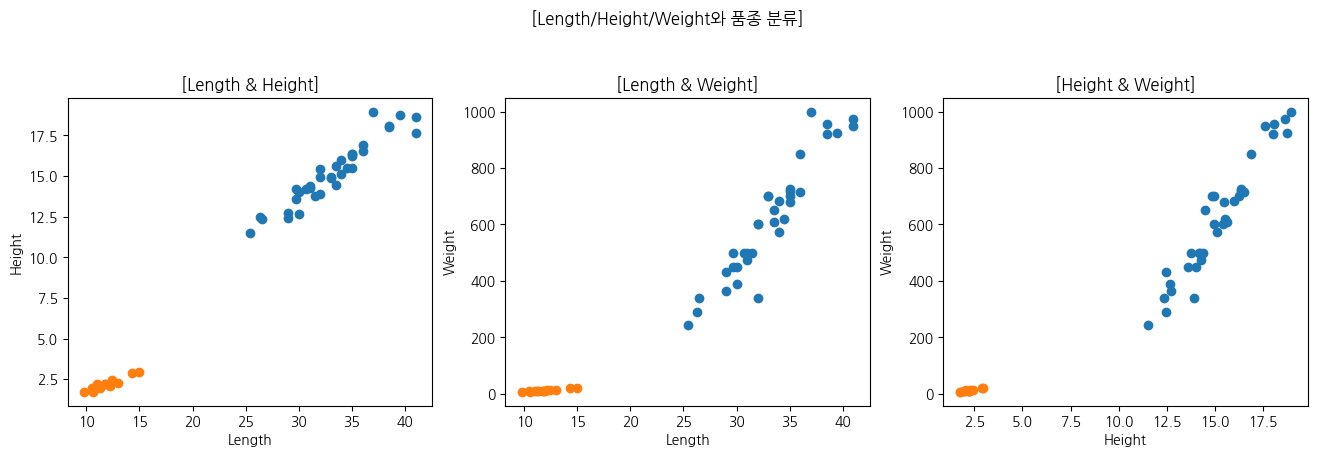

In [10]:
## 길이, 높이 => 2개 품종 식별 체크 | 길이, 무게 => 2개 품종 식별 체크 | 높이, 무게 => 2개 품종 식별 체크
## - 1행 3열, 품종별 다른 색상, 산점도
cols = [['Length', 'Height'], ['Length', 'Weight'], ['Height', 'Weight']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col1, col2) in zip(axes, cols):
    breamDF = fishDF[fishDF['Species'] == 'Bream']
    smeltDF = fishDF[fishDF['Species'] == 'Smelt']

    ax.scatter(breamDF[col1], breamDF[col2], label='Bream')
    ax.scatter(smeltDF[col1], smeltDF[col2], label='Smelt')

    ax.set_title(f'[{col1} & {col2}]')
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)

plt.suptitle('[Length/Height/Weight와 품종 분류]', y=1.1)
plt.show()

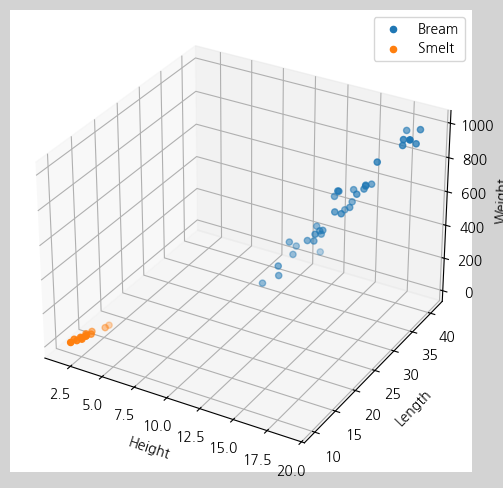

In [11]:
fig = plt.figure(figsize=(6, 6), facecolor= 'lightgray', edgecolor= 'black')
ax = plt.axes(projection='3d')


ax.scatter(breamDF['Height'], breamDF['Length'], breamDF['Weight'], label='Bream')
ax.scatter(smeltDF['Height'], smeltDF['Length'], smeltDF['Weight'], label='Smelt')

ax.set_xlabel('Height')
ax.set_ylabel('Length')
ax.set_zlabel('Weight')

plt.legend()
plt.show()

- **[3] 데이터셋 준비**
    * 피쳐와 타겟 분리ㅡ
    * 학습용과 테스트용 분리

In [12]:
## 피처와 타겟 분리
featureDF= fishDF[fishDF.columns[1:]]
targetSR= fishDF[fishDF.columns[0]]

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')


피쳐 : (49, 3), 타겟 : (49,)


In [13]:
### 학습용, 테스트용 분리: 분류 모델로 클래스/ 타겟 비율 유지
X_train, X_test, y_train, y_test= train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size= 0.2,
                                                    random_state= 42,
                                                    stratify= targetSR)

In [14]:
## 확인
print('[학습용]-------')
print(f'x_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'y_train: {(y_train.value_counts() / y_train.shape[0]).to_list()}')

print('\n\n[테스트용]-------')
print(f'x_test: {X_test.shape}, y_test: {y_test.shape}')
print(f'y_test: {(y_test.value_counts() / y_test.shape[0]).to_list()}')

[학습용]-------
x_train: (39, 3), y_train: (39,)
y_train: [0.717948717948718, 0.28205128205128205]


[테스트용]-------
x_test: (10, 3), y_test: (10,)
y_test: [0.7, 0.3]


- **[4] 학습**

In [15]:
## 파라미터
params = {'n_neighbors': range(3, 30, 2)}

model = KNeighborsClassifier()
scv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gsModel = GridSearchCV(
    model,
    param_grid=params,
    cv=scv,
    return_train_score=True
)

In [16]:
## => 교차검증 학습 진행
gsModel.fit(X_train, y_train)

c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(3, 30, 2)},
             return_train_score=True)

In [17]:
## => 결과 분석
sel_cols = ['rank_test_score', 'param_n_neighbors',
            'mean_test_score', 'std_test_score',
            'mean_train_score', 'std_train_score']

cvDF = pd.DataFrame(gsModel.cv_results_, columns=sel_cols)

In [18]:
cvDF.head()

,rank_test_score,param_n_neighbors,mean_test_score,std_test_score,mean_train_score,std_train_score
0,1,3,1.000,0.00,1.0,0.0
1,1,5,1.000,0.00,1.0,0.0
2,1,7,1.000,0.00,1.0,0.0
3,1,9,1.000,0.00,1.0,0.0
4,5,11,0.975,0.05,1.0,0.0


In [22]:
# cv_resultDF = pd.DataFrame(gsModel.cv_results_)


# ## => 최적 모델 확인
# print('최적 파라미터:', gsModel.best_params_)
# print('최고 교차검증 점수:', gsModel.best_score_)

# ## => 최고 성능 모델 저장
bestModel = gsModel.best_estimator_

# ## => 학습/테스트 점수 확인
# print(f'GridSearchCV 점수: {bestModel.score(X_train, y_train):.4f}')
# print("GridSearchCV 테스트 점수:", bestModel.score(X_test, y_test))


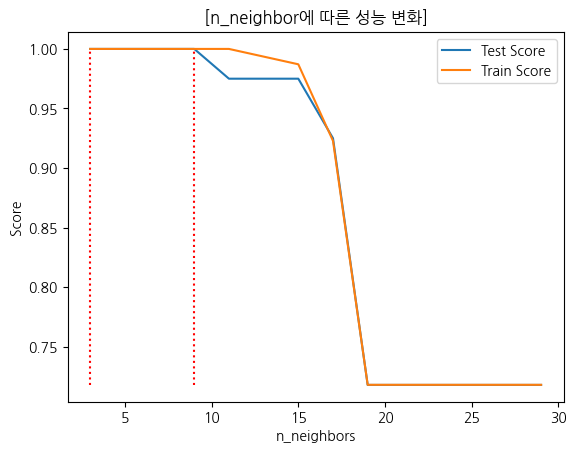

In [27]:
## n_neighbors 값 변화에 따른 훈련 점수/ 테스트(검증) 점수 변화 시각화 

sortDF = cvDF.sort_values(by=['param_n_neighbors'])

# 테스트/ 검증 점수, 훈련 점수
plt.plot(sortDF['param_n_neighbors'], sortDF['mean_test_score'], label='Test Score')
plt.plot(sortDF['param_n_neighbors'], sortDF['mean_train_score'], label='Train Score')


## - n_neighbor 구간
plt.vlines(3, cvDF['mean_test_score'].min(), cvDF['mean_test_score'].max(),
           colors='red', linestyles='dotted')
plt.vlines(9, cvDF['mean_test_score'].min(), cvDF['mean_test_score'].max(),
           colors='red', linestyles='dotted')
plt.xlabel('n_neighbors')
plt.ylabel('Score')
plt.title('[n_neighbor에 따른 성능 변화]')
plt.legend()
plt.show()

In [24]:
cv_resultDF = pd.DataFrame(gsModel.cv_results_)


## => 최적 모델 확인
print('최적 파라미터:', gsModel.best_params_)
print('최고 교차검증 점수:', gsModel.best_score_)

## => 최고 성능 모델 저장
bestModel = gsModel.best_estimator_

## => 학습/테스트 점수 확인
print(f'GridSearchCV 점수: {bestModel.score(X_train, y_train):.4f}')
print("GridSearchCV 테스트 점수:", bestModel.score(X_test, y_test))


최적 파라미터: {'n_neighbors': 3}
최고 교차검증 점수: 1.0
GridSearchCV 점수: 1.0000
GridSearchCV 테스트 점수: 1.0


- **[5] 예측**
    * 테스트 데이터셋 예측
    * 실제 데이터셋 예측

In [28]:
## => 테스트 데이터셋 예측
y_pre = bestModel.predict(X_test)

compareDF = pd.DataFrame(
    np.vstack([y_test, y_pre]),
    index=['정답', '예측']
).T

compareDF['결과'] = compareDF['정답'] == compareDF['예측']

compareDF

,정답,예측,결과
0,Bream,Bream,True
1,Bream,Bream,True
2,Smelt,Smelt,True
3,Bream,Bream,True
4,Bream,Bream,True
5,Smelt,Smelt,True
6,Smelt,Smelt,True
7,Bream,Bream,True
8,Bream,Bream,True
9,Bream,Bream,True


In [30]:
## => 테스트 데이터셋 예측
y_pre = bestModel.predict(X_test)

## 정답과 비교
compareDF = pd.DataFrame(np.vstack([y_test, y_pre]), index=['정답', '예측']).T
compareDF['결과'] = compareDF['정답'] == compareDF['예측']

## 집계
correct, incorrect = compareDF['결과'].sum(), compareDF.shape[0] - compareDF['결과'].sum()

print(f'[결과] 정답 수 : {correct}개, 오답 수 : {incorrect}개')

[결과] 정답 수 : 10개, 오답 수 : 0개


In [52]:
## ------------------------------------------
## => 임의의 데이터 예측  6.9, 9.2, 1.96
##                     255, 27.4, 11.99
##                     150, 25, 3.92
## ------------------------------------------


new_data = pd. DataFrame([[6.9,9.2,1.96], [255,27.4,11.99], [150, 25, 3.92]],
                          columns=X_train.columns)
y_pre = bestModel. predict(new_data)

print(f'[에측] : {y_pre}| [정답]: smelt, Bream, ?')

[에측] : ['Smelt' 'Bream' 'Smelt']| [정답]: smelt, Bream, ?


In [40]:
bestModel.kneighbors()

(array([[1.01137542e+01, 2.01558223e+01, 5.00317867e+01],
        [2.50447280e-01, 8.24815379e-01, 8.54587860e-01],
        [3.33117157e-01, 9.26532655e-01, 2.50018261e+01],
        [6.08474215e+00, 2.00003678e+01, 2.01501168e+01],
        [6.59515518e+00, 7.82765289e+00, 1.00386328e+01],
        [1.26306301e+00, 3.45929172e+00, 3.55762550e+00],
        [1.26306301e+00, 2.23947589e+00, 2.33778790e+00],
        [4.80180341e+01, 9.80099272e+01, 9.82511372e+01],
        [5.12597552e+00, 2.00148902e+01, 2.01067535e+01],
        [1.08829327e+00, 1.44223384e+00, 2.26719562e+00],
        [2.50447280e-01, 6.22159537e-01, 6.45819239e-01],
        [5.14922512e+00, 3.00241431e+01, 5.00226360e+01],
        [6.08474215e+00, 1.40383921e+01, 1.44046257e+01],
        [4.80180341e+01, 5.00005044e+01, 5.03442470e+01],
        [7.76000000e-02, 2.42995391e+00, 1.44133384e+01],
        [5.14922512e+00, 3.50000317e+01, 5.50600418e+01],
        [2.53200203e+01, 4.50334557e+01, 7.50419291e+01],
        [1.000

In [55]:

distance, indices = bestModel.kneighbors(new_data)
# distance, indices=> kneighbors()메서드 : K개의 이웃 데이터 인덱스와 길이값 반환

distance, indices

(array([[  0.67002197,   1.43183239,   2.76592322],
        [ 13.16134112,  35.02070959,  85.00564916],
        [ 92.31424592, 130.74278805, 137.1879736 ]]),
 array([[29,  9, 25],
        [ 7, 13, 32],
        [ 7,  4,  5]]))

In [57]:
## 학습 데이터셋: 인덱스 정리=> train_test_split() 에서 데이터셋 섞으면 인덱스 섞여짐

X_train2= X_train.reset_index(drop=True)
X_train2

## => 친구 데이터 확인
print("==> 첫번째 데이터의 최근접 이웃데이터\n ", X_train2.iloc[indices[0]])
print("\n\n==> 두번째 데이터의 최근접 이웃데이터\n", X_train2.iloc[indices[1]])
print("\n\n==> 세번째 데이터의 최근접 이웃데이터\n", X_train2.iloc[indices[2]])


==> 첫번째 데이터의 최근접 이웃데이터
      Weight  Length  Height
29     6.7     9.8  1.7388
9      7.5    10.5  1.9720
25     8.7    11.3  1.9782


==> 두번째 데이터의 최근접 이웃데이터
     Weight  Length   Height
7    242.0    25.4  11.5200
13   290.0    26.3  12.4800
32   340.0    26.5  12.3778


==> 세번째 데이터의 최근접 이웃데이터
    Weight  Length   Height
7   242.0    25.4  11.5200
4    19.7    14.3   2.8728
5    13.4    12.4   2.4300


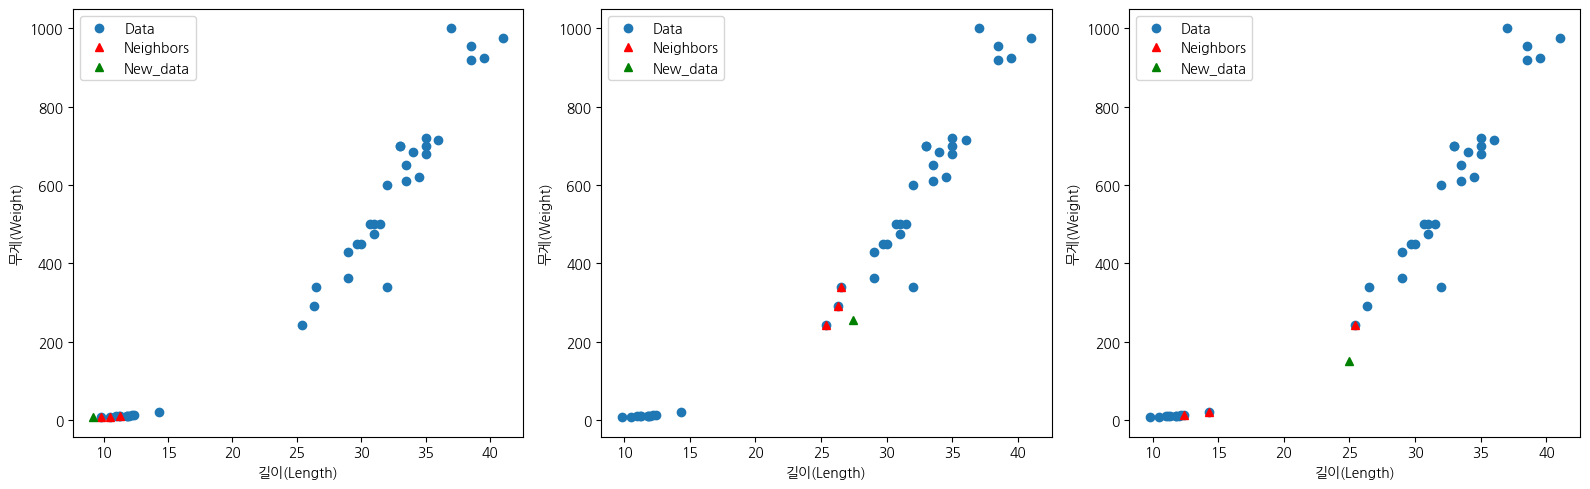

In [62]:
## ---------------------------------------
## ==> 데이터와 최근접이웃데이터들 시각화
## => 2개의 데이터에 대한 이웃데이터: 1행 2열 길이 Length, 무게 Weight
## ---------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, idx in zip(axes, [0, 1, 2]):
    neighborSR = X_train2.iloc[indices[idx]]
    dataSR = new_data.iloc[idx]

    ax.scatter(X_train2['Length'], X_train2['Weight'], label='Data')

    ax.plot(neighborSR['Length'], neighborSR['Weight'], 'r^', label='Neighbors')

    ax.plot(dataSR['Length'], dataSR['Weight'], 'g^', label='New_data')
    ax.set_xlabel('길이(Length)')
    ax.set_ylabel('무게(Weight)')
    ax.legend()

plt.tight_layout()
plt.show()